# UFC Fight Analysis

## 1. Data Loading & Setup

In this notebook we analyse UFC fight data scraped from ufcstats.com, covering events from 2010 onwards. The goal is to discover patterns in fighting styles, understand what factors influence fight outcomes, and build the foundation for a fighter rating system.

**Datasets used:**
- `ufc_fights.csv` — 8,688 fights with detailed statistics
- `ufc_fighters.csv` — 4,490 fighter profiles
- `UFC_betting_odds.csv` — betting odds from multiple bookmakers



Before starting the analysis, we load the three main datasets and apply basic preprocessing:

- **Date parsing**: converting event dates to datetime format
- **Year extraction**: to enable time-based analysis
- **Modern filter**: restricting to fights from 2010 onwards, when MMA became a fully integrated combat sport with consistent rules, training methods and data coverage

Fights before 2010 are excluded for two reasons: the sport was significantly different in its early years (specialist fighters, inconsistent rules), and data quality drops considerably for older events.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

# Load data
fights = pd.read_csv('../Data/ufc_fights.csv', dtype=str, encoding='utf-8-sig')
fighters = pd.read_csv('../Data/ufc_fighters.csv', dtype=str, encoding='utf-8-sig')
champions = pd.read_csv('../Data/ufc_champions.csv', dtype=str, encoding='utf-8-sig')

# Parse dates
fights['event_date'] = pd.to_datetime(fights['event_date'], format='%B %d, %Y', errors='coerce')
fights['year'] = fights['event_date'].dt.year

# Filter from 2010
fights_modern = fights[fights['year'] >= 2010].copy()

# Summary
print('Total fights: ' + str(len(fights)))
print('Fights from 2010: ' + str(len(fights_modern)))
print('Fighters: ' + str(len(fighters)))
print('Champions: ' + str(len(champions)))

Total fights: 8688
Fights from 2010: 7423
Fighters: 4490
Champions: 146


## 2. The UFC in Numbers

Before diving into fight statistics, we start with a broad view of the organisation, how it has grown over time, which weight classes are most active, and how fights end.

### 2.1 Growth Over Time

The first question is simple: how has the UFC grown? Looking at the number of fights per year gives us a clear picture of the organisation's expansion and any external disruptions.


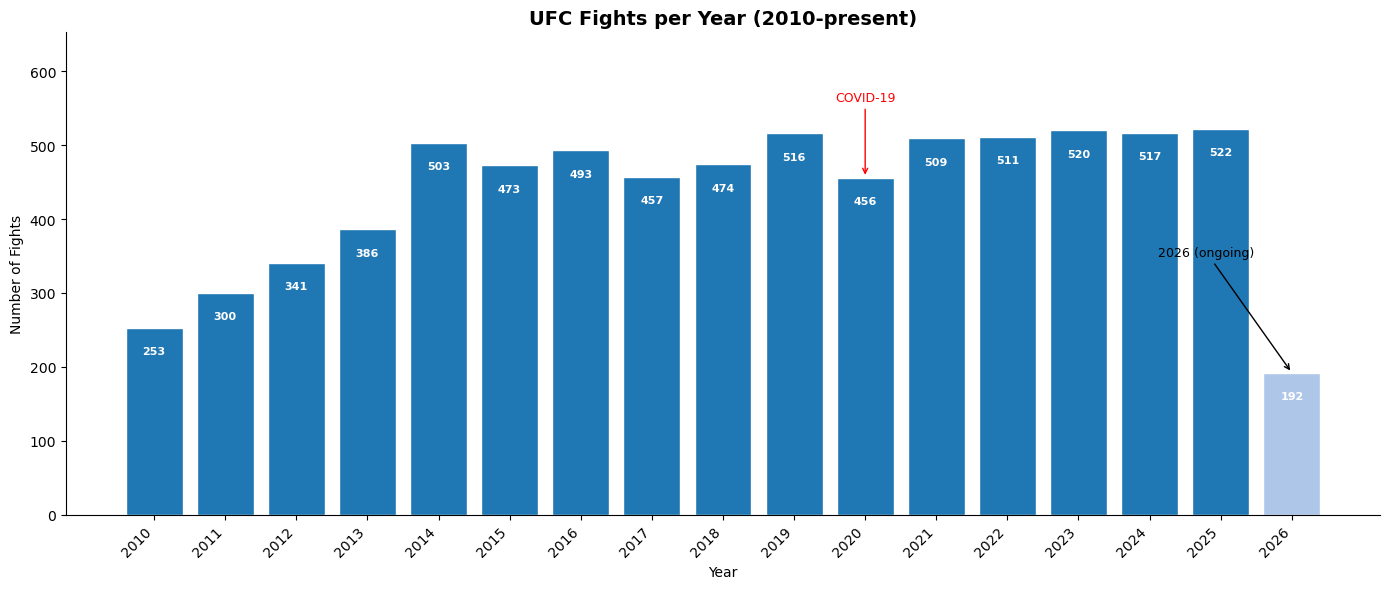

In [20]:
# Count fights per year
fights_per_year = fights_modern.groupby('year').size().reset_index(name='fights')

# Color 2026 differently (incomplete year)
colors = ['#aec7e8' if year == 2026 else '#1f77b4' for year in fights_per_year['year']]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(fights_per_year['year'], fights_per_year['fights'], color=colors, edgecolor='white')

# Add number on top of each bar
for bar, val in zip(bars, fights_per_year['fights']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 25,
            str(val), ha='center', va='top', fontsize=8, color='white', fontweight='bold')

# Annotations
ax.annotate('COVID-19', xy=(2020, 456), xytext=(2020, 560),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red', ha='center')

ax.annotate('2026 (ongoing)', xy=(2026, 192), xytext=(2024.8, 350),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='black', ha='center')

# Labels and formatting
ax.set_title('UFC Fights per Year (2010-present)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Fights')
ax.set_xticks(fights_per_year['year'])
ax.set_xticklabels(fights_per_year['year'], rotation=45, ha='right')
ax.set_ylim(0, fights_per_year['fights'].max() * 1.25)

plt.tight_layout()
plt.show()

The UFC has grown from 253 fights in 2010 to a stable plateau of around 500–520 fights per year since 2019. 

The growth phase (2010–2014) likely reflects the organisation's aggressive international expansion under Zuffa ownership, opening new markets in Europe, Asia and Latin America. 

The stabilisation since 2019 suggests the UFC has reached a natural ceiling given the number of ranked fighters per division and the constraints of the event calendar. 

The 2020 dip caused by COVID-19 was recovered within a year, which speaks to the UFC's operational resilience. They were one of the first sports organisations to resume activity using a controlled bubble format.

### 2.2 Activity by Weight Class

Not all divisions are equal. Some weight classes have far more fighters and events than others. Understanding which divisions are most active helps contextualise the rest of the analysis.

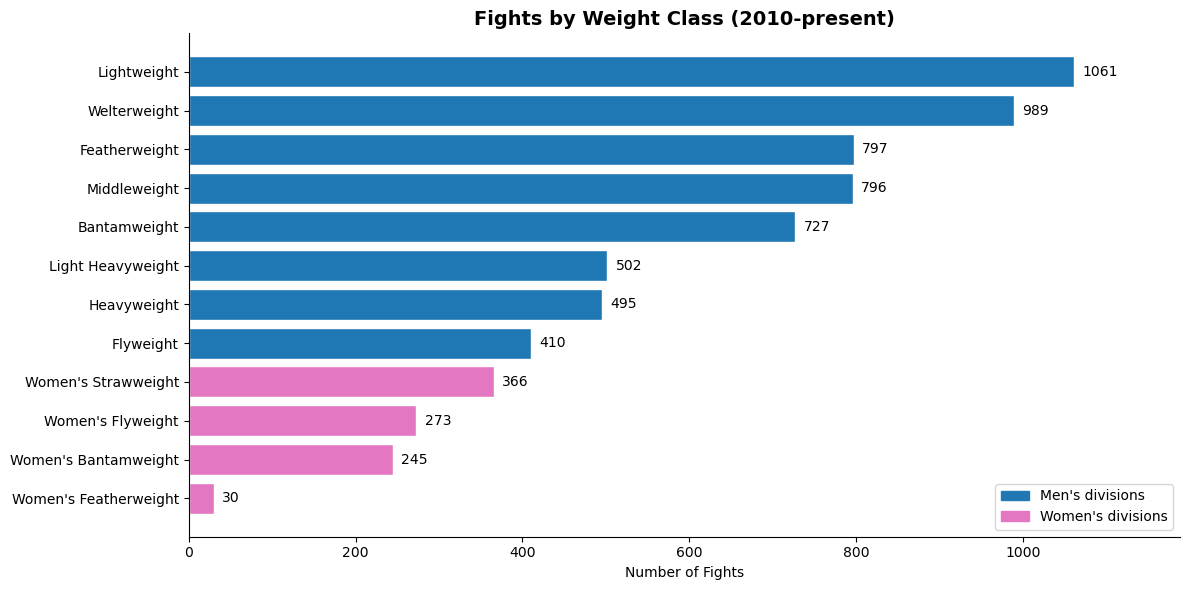

In [21]:
# Count fights per weight class (exclude Catch Weight and empty)
weight_counts = fights_modern[~fights_modern['weight_class'].isin(['Catch Weight', ''])]['weight_class'].value_counts().head(12).sort_values()

# Color women's divisions differently
colors = ['#e377c2' if 'Women' in w else '#1f77b4' for w in weight_counts.index]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(weight_counts.index, weight_counts.values, color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, weight_counts.values):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)

# Labels and formatting
ax.set_title('Fights by Weight Class (2010-present)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Fights')
ax.set_xlim(0, weight_counts.max() * 1.12)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#1f77b4', label="Men's divisions"),
          Patch(color='#e377c2', label="Women's divisions")]
ax.legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.show()

Lightweight and Welterweight dominate activity with over 1,000 and 989 fights respectively. 

This is not coincidental — these are the most competitive divisions globally, with the deepest talent pools drawn from wrestling, boxing and kickboxing traditions across multiple continents. 

Heavier divisions like Heavyweight and Light Heavyweight show significantly lower numbers, partly because elite heavyweights are rarer athletes and partly because their fights carry higher injury risk, leading to longer recovery periods between bouts.

Women's divisions, introduced from 2013 onwards, have grown steadily, suggesting the UFC has successfully developed female MMA as a product rather than a novelty.
    

### 2.3 Finish Methods

How do UFC fights end? Understanding the distribution of finishes (knockouts, submissions and decisions) gives us a first look at the nature of the sport and whether it has become more or less violent over time.

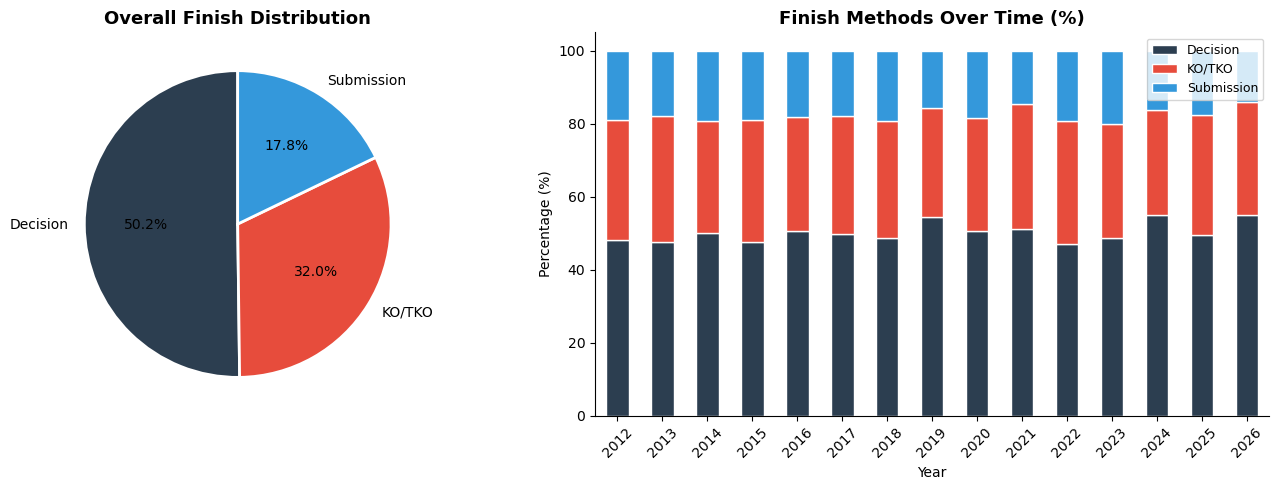

In [22]:
# Classify finish method
def categorize_method(method):
    if pd.isna(method) or method == '':
        return None
    method = str(method).upper()
    if 'KO' in method or 'TKO' in method:
        return 'KO/TKO'
    elif 'SUB' in method:
        return 'Submission'
    elif 'DEC' in method:
        return 'Decision'
    return None

fights_modern['finish_category'] = fights_modern['method'].apply(categorize_method)

# Only valid categories
valid = fights_modern['finish_category'].notna()
finish_counts = fights_modern[valid]['finish_category'].value_counts()

# Colors per category
color_map = {'Decision': '#2C3E50', 'KO/TKO': '#E74C3C', 'Submission': '#3498DB'}
colors_pie = [color_map[c] for c in finish_counts.index]

# Two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left - pie chart
axes[0].pie(finish_counts.values, labels=finish_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Overall Finish Distribution', fontsize=13, fontweight='bold')

# Right - stacked bar chart over time
finish_by_year = fights_modern[valid].groupby(['year', 'finish_category']).size().unstack(fill_value=0)
finish_by_year_pct = finish_by_year.div(finish_by_year.sum(axis=1), axis=0) * 100
colors_bar = [color_map[c] for c in finish_by_year_pct.columns]

finish_by_year_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors_bar, edgecolor='white')
axes[1].set_title('Finish Methods Over Time (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

Decisions account for just over half of all fights (50.2%), with KO/TKO at 32% and submissions at 17.8%. 

The stability of these proportions over time is arguably the most interesting finding. Despite the popular narrative that modern MMA has become more violent or more submission-heavy, the data shows almost no change since 2012. 

A plausible explanation is that as offensive techniques improve, so does defensive training. 

Fighters today are better at surviving knockout attempts and defending submissions than ever before, which keeps the decision rate high. 

The submission rate being the lowest may reflect the dominance of wrestling over pure BJJ, wrestlers can control position without necessarily finishing.

### 2.4 Championship History

Who has dominated the UFC? Using the championship history dataset, we look at which divisions have had the most title changes, which fighters have held the belt longest, and who has made the most successful defenses.

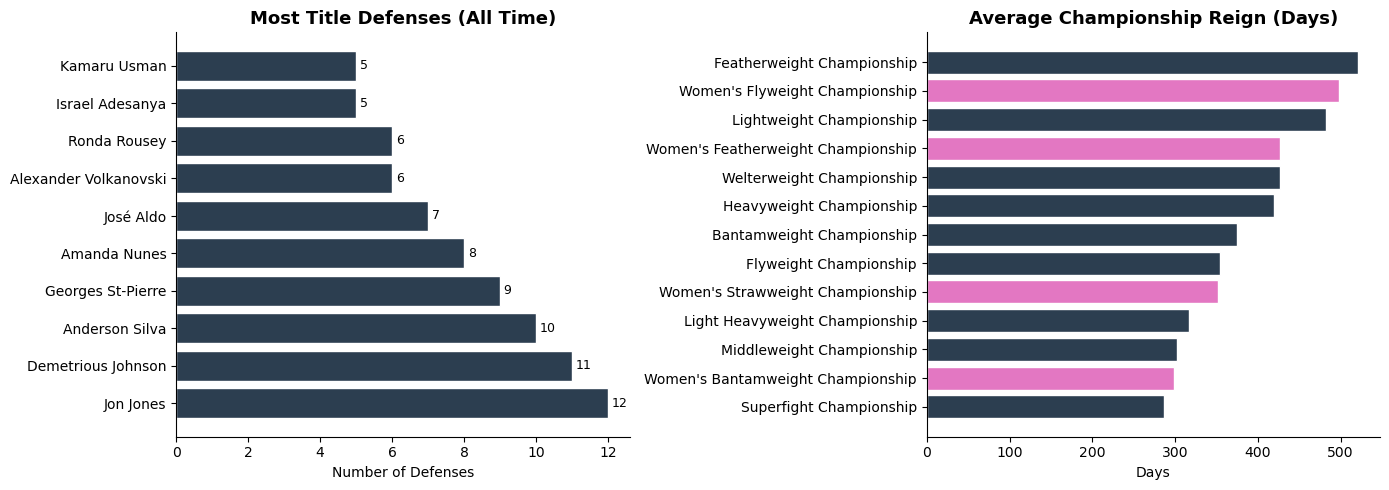

In [23]:
# Reload champions with updated defenses
champions = pd.read_csv('../Data/ufc_champions.csv', dtype=str, encoding='utf-8-sig')

# Convert numeric columns
champions['defenses_count'] = pd.to_numeric(champions['defenses_count'], errors='coerce').fillna(0)
champions['reign_days'] = pd.to_numeric(champions['reign_days'], errors='coerce')

# Top 10 fighters by total defenses across all divisions
max_defenses = champions.groupby(['champion', 'division'])['defenses_count'].max().reset_index()
total_defenses = max_defenses.groupby('champion')['defenses_count'].sum().sort_values(ascending=False).head(10)

# Average reign length per division
avg_reign = champions[champions['reign_days'].notna()].groupby('division')['reign_days'].mean().sort_values()
colors_div = ['#e377c2' if 'Women' in d else '#2C3E50' for d in avg_reign.index]

# Two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left - most title defenses
axes[0].barh(total_defenses.index, total_defenses.values, color='#2C3E50', edgecolor='white')
axes[0].set_title('Most Title Defenses (All Time)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Defenses')
for i, val in enumerate(total_defenses.values):
    axes[0].text(val + 0.1, i, str(int(val)), va='center', fontsize=9)

# Right - average reign days by division
axes[1].barh(avg_reign.index, avg_reign.values, color=colors_div, edgecolor='white')
axes[1].set_title('Average Championship Reign (Days)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Days')

plt.tight_layout()
plt.show()

Jon Jones leads all-time with 12 title defenses, followed by Demetrious Johnson (11) and Anderson Silva (10).

On average, Featherweight reigns last the longest (~520 days), largely driven by José Aldo's dominant era.

Women's divisions show competitive reign lengths despite being introduced later (from 2013).

## 3. What Decides a Fight?

The core question of this analysis: what actually makes a fighter win? Beyond the highlights and narratives, the data allows us to look for patterns: which statistics correlate most strongly with winning, and which are just noise.

We approach this question from three angles: striking output and accuracy, takedowns and ground control, and physical attributes. Each section tests a common assumption about what wins fights in the UFC.

### 3.1 Striking: Volume vs Accuracy

The first assumption to test: does the fighter who throws more win, or the fighter who lands more accurately? We compare significant strikes landed, attempted, and accuracy between winners and losers.

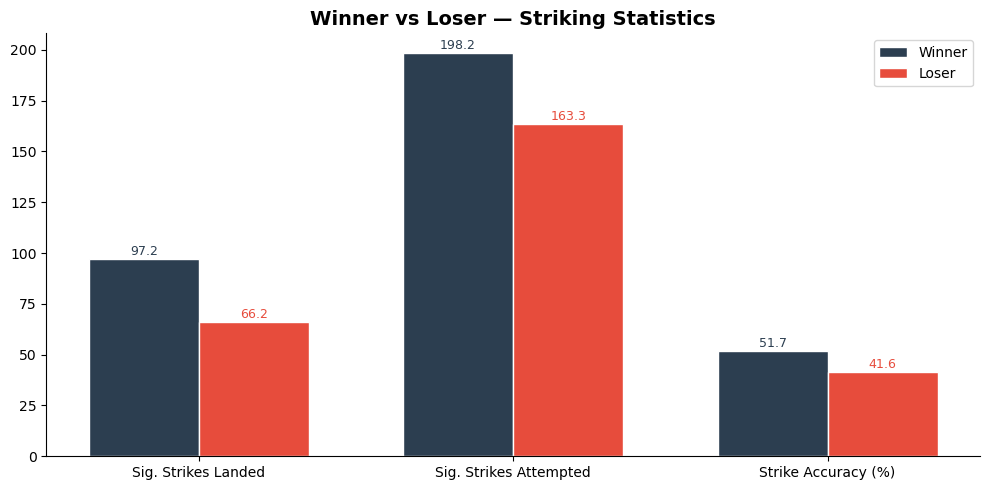

Winners land 97.2 sig strikes vs losers 66.2
Winners are 51.7% accurate vs losers 41.6%


In [24]:
# Convert numeric columns
numeric_cols = ['significant_strikes_landed_1', 'significant_strikes_att_1',
                'significant_strikes_landed_2', 'significant_strikes_att_2',
                'sig_strikes_accuracy_1', 'sig_strikes_accuracy_2']

for col in numeric_cols:
    fights_modern[col] = pd.to_numeric(fights_modern[col], errors='coerce')

# Separate fights where fighter 1 won vs fighter 2 won
f1_wins = fights_modern[fights_modern['winner'] == fights_modern['fighter_1']].copy()
f2_wins = fights_modern[fights_modern['winner'] == fights_modern['fighter_2']].copy()

# Rename columns so winner/loser stats are always in the same column name
f1_wins['winner_sig_landed'] = f1_wins['significant_strikes_landed_1']
f1_wins['loser_sig_landed']  = f1_wins['significant_strikes_landed_2']
f1_wins['winner_sig_att']    = f1_wins['significant_strikes_att_1']
f1_wins['loser_sig_att']     = f1_wins['significant_strikes_att_2']
f1_wins['winner_accuracy']   = f1_wins['sig_strikes_accuracy_1']
f1_wins['loser_accuracy']    = f1_wins['sig_strikes_accuracy_2']

f2_wins['winner_sig_landed'] = f2_wins['significant_strikes_landed_2']
f2_wins['loser_sig_landed']  = f2_wins['significant_strikes_landed_1']
f2_wins['winner_sig_att']    = f2_wins['significant_strikes_att_2']
f2_wins['loser_sig_att']     = f2_wins['significant_strikes_att_1']
f2_wins['winner_accuracy']   = f2_wins['sig_strikes_accuracy_2']
f2_wins['loser_accuracy']    = f2_wins['sig_strikes_accuracy_1']

# Combine both into one dataframe
df_w = pd.concat([f1_wins, f2_wins])

# Calculate averages for each stat
labels = ['Sig. Strikes Landed', 'Sig. Strikes Attempted', 'Strike Accuracy (%)']
winner_vals = [
    df_w['winner_sig_landed'].mean(),
    df_w['winner_sig_att'].mean(),
    df_w['winner_accuracy'].mean() * 100
]
loser_vals = [
    df_w['loser_sig_landed'].mean(),
    df_w['loser_sig_att'].mean(),
    df_w['loser_accuracy'].mean() * 100
]

# Plot grouped bar chart
x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], winner_vals, width, label='Winner', color='#2C3E50', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], loser_vals,  width, label='Loser',  color='#E74C3C', edgecolor='white')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, color='#2C3E50')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, color='#E74C3C')

ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_title('Winner vs Loser — Striking Statistics', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print('Winners land ' + str(round(winner_vals[0], 1)) + ' sig strikes vs losers ' + str(round(loser_vals[0], 1)))
print('Winners are ' + str(round(winner_vals[2], 1)) + '% accurate vs losers ' + str(round(loser_vals[2], 1)) + '%')

Winners land significantly more significant strikes than losers (97.2 vs 66.2), and also attempt more (198.2 vs 163.3). 

Both volume and accuracy correlate with winning, but the gap in accuracy (51.7% vs 41.6%) is proportionally smaller than the gap in volume. 

This suggests that in UFC fighting, output pressure matters as much as precision — a fighter who throws constantly forces their opponent into defensive positions, creates openings, and scores on the judges' scorecards even when not landing cleanly. 

The "accuracy over volume" debate in striking coaching may be less clear-cut than theory suggests.

### 3.2 Takedowns and Ground Control

Striking is not the only path to victory. Wrestling and ground control have always been central to MMA. Here we test whether takedowns and control time correlate with winning as strongly as striking does.

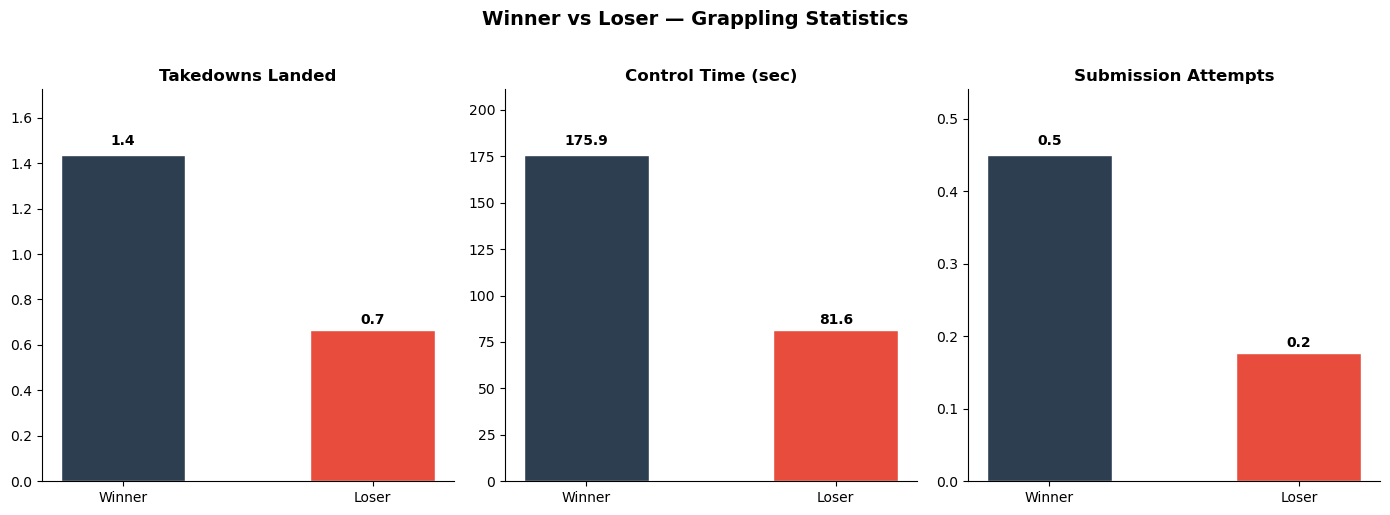

In [25]:
# Convert numeric columns
td_cols = ['takedowns_succ_1', 'takedowns_att_1', 'takedowns_succ_2', 'takedowns_att_2',
           'control_time_seconds_1', 'control_time_seconds_2', 'subs_att_1', 'subs_att_2']

for col in td_cols:
    fights_modern[col] = pd.to_numeric(fights_modern[col], errors='coerce')

# Recalculate f1_wins and f2_wins
f1_wins = fights_modern[fights_modern['winner'] == fights_modern['fighter_1']].copy()
f2_wins = fights_modern[fights_modern['winner'] == fights_modern['fighter_2']].copy()

f1_wins['winner_td_succ'] = pd.to_numeric(f1_wins['takedowns_succ_1'], errors='coerce')
f1_wins['loser_td_succ'] = pd.to_numeric(f1_wins['takedowns_succ_2'], errors='coerce')
f1_wins['winner_control'] = pd.to_numeric(f1_wins['control_time_seconds_1'], errors='coerce')
f1_wins['loser_control'] = pd.to_numeric(f1_wins['control_time_seconds_2'], errors='coerce')
f1_wins['winner_subs'] = pd.to_numeric(f1_wins['subs_att_1'], errors='coerce')
f1_wins['loser_subs'] = pd.to_numeric(f1_wins['subs_att_2'], errors='coerce')

f2_wins['winner_td_succ'] = pd.to_numeric(f2_wins['takedowns_succ_2'], errors='coerce')
f2_wins['loser_td_succ'] = pd.to_numeric(f2_wins['takedowns_succ_1'], errors='coerce')
f2_wins['winner_control'] = pd.to_numeric(f2_wins['control_time_seconds_2'], errors='coerce')
f2_wins['loser_control'] = pd.to_numeric(f2_wins['control_time_seconds_1'], errors='coerce')
f2_wins['winner_subs'] = pd.to_numeric(f2_wins['subs_att_2'], errors='coerce')
f2_wins['loser_subs'] = pd.to_numeric(f2_wins['subs_att_1'], errors='coerce')

df_w = pd.concat([f1_wins, f2_wins])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ('Takedowns Landed', 'winner_td_succ', 'loser_td_succ'),
    ('Control Time (sec)', 'winner_control', 'loser_control'),
    ('Submission Attempts', 'winner_subs', 'loser_subs'),
]

for i, (title, w_col, l_col) in enumerate(metrics):
    w_val = df_w[w_col].mean()
    l_val = df_w[l_col].mean()

    bars = axes[i].bar(['Winner', 'Loser'], [w_val, l_val],
                       color=['#2C3E50', '#E74C3C'], edgecolor='white', width=0.5)

    for bar, val in zip(bars, [w_val, l_val]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.02,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].set_ylim(0, max(w_val, l_val) * 1.2)

plt.suptitle('Winner vs Loser — Grappling Statistics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Ground control shows the strongest differential between winners and losers. 

Winners accumulate 175.9 seconds of control time on average compared to just 81.6 for losers,  more than double. 

Takedowns also clearly favour winners (1.4 vs 0.7), as do submission attempts (0.5 vs 0.2). 

The control time gap is particularly striking, it suggests that the ability to dictate where the fight takes place is one of the most decisive factors in MMA. 

A wrestler who can take the fight to the ground and hold position not only scores points but also denies the opponent their preferred range and pace. 

This may explain why elite wrestlers have historically dominated the sport even without high finishing rates.

### 3.3 Striking: Volume vs Accuracy

The first assumption to test: does the fighter who throws more win, or the fighter who lands more accurately? 

We compare significant strikes landed, attempted, and accuracy between winners and losers.

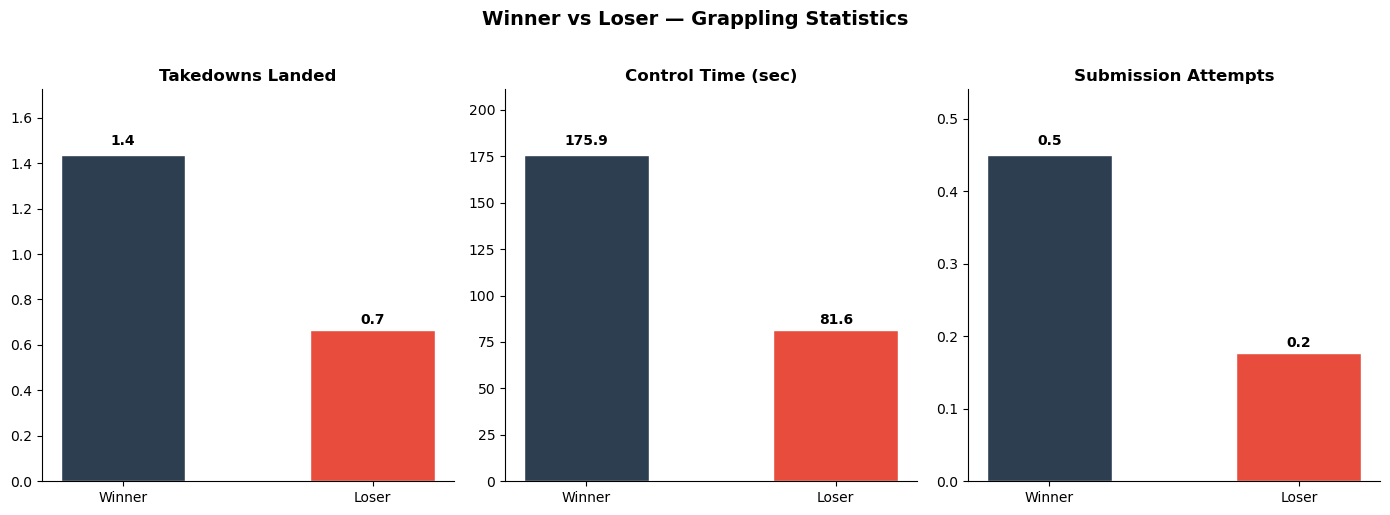

In [26]:
# Convert numeric columns
td_cols = ['takedowns_succ_1', 'takedowns_att_1', 'takedowns_succ_2', 'takedowns_att_2',
           'control_time_seconds_1', 'control_time_seconds_2', 'subs_att_1', 'subs_att_2']

for col in td_cols:
    fights_modern[col] = pd.to_numeric(fights_modern[col], errors='coerce')

# Separate fights by winner
f1_wins = fights_modern[fights_modern['winner'] == fights_modern['fighter_1']].copy()
f2_wins = fights_modern[fights_modern['winner'] == fights_modern['fighter_2']].copy()

# Rename columns so winner/loser stats are always in the same column name
f1_wins['winner_td_succ'] = f1_wins['takedowns_succ_1']
f1_wins['loser_td_succ']  = f1_wins['takedowns_succ_2']
f1_wins['winner_control'] = f1_wins['control_time_seconds_1']
f1_wins['loser_control']  = f1_wins['control_time_seconds_2']
f1_wins['winner_subs']    = f1_wins['subs_att_1']
f1_wins['loser_subs']     = f1_wins['subs_att_2']

f2_wins['winner_td_succ'] = f2_wins['takedowns_succ_2']
f2_wins['loser_td_succ']  = f2_wins['takedowns_succ_1']
f2_wins['winner_control'] = f2_wins['control_time_seconds_2']
f2_wins['loser_control']  = f2_wins['control_time_seconds_1']
f2_wins['winner_subs']    = f2_wins['subs_att_2']
f2_wins['loser_subs']     = f2_wins['subs_att_1']

# Combine both
df_w = pd.concat([f1_wins, f2_wins])

# Three metrics to compare
metrics = [
    ('Takedowns Landed',    'winner_td_succ', 'loser_td_succ'),
    ('Control Time (sec)',  'winner_control',  'loser_control'),
    ('Submission Attempts', 'winner_subs',     'loser_subs'),
]

# Plot one bar chart per metric
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, (title, w_col, l_col) in enumerate(metrics):
    w_val = df_w[w_col].mean()
    l_val = df_w[l_col].mean()

    bars = axes[i].bar(['Winner', 'Loser'], [w_val, l_val],
                       color=['#2C3E50', '#E74C3C'], edgecolor='white', width=0.5)

    # Value labels on bars
    for bar, val in zip(bars, [w_val, l_val]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, max(w_val, l_val) * 1.2)

plt.suptitle('Winner vs Loser — Grappling Statistics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The results are counterintuitive. Fighters with a reach advantage actually win slightly less often (46.8%) than those without one, and the same applies to height (46.5%). 

There are several possible explanations for this. 

First, matchmaking bias: the UFC tends to match fighters of similar physical profiles, so reach and height advantages are rarely extreme enough to be decisive. 

Second,  sample composition: fighters with longer reach are often taller and compete at higher weight classes where finishing rates are lower. 

Third, and perhaps most importantly,  physical attributes are already priced in: coaches and fighters are well aware of reach disadvantages and train specifically to negate them (e.g. wrestlers closing distance, pressure fighters working inside).

The only modest physical edge comes from being southpaw, which wins 51.4% of fights against orthodox opponents, likely due to the relative unfamiliarity of dealing with a left-handed fighter. 

Even this advantage is small, suggesting that in elite MMA, physical attributes matter far less than skills and game planning.

### 3.4 Odds vs Reality

Betting markets aggregate the opinions of thousands of bettors and bookmakers. If the market is efficient, the favourite should win most of the time. 

Here we test how often the betting favourite actually wins, and whether some divisions are more predictable than others.

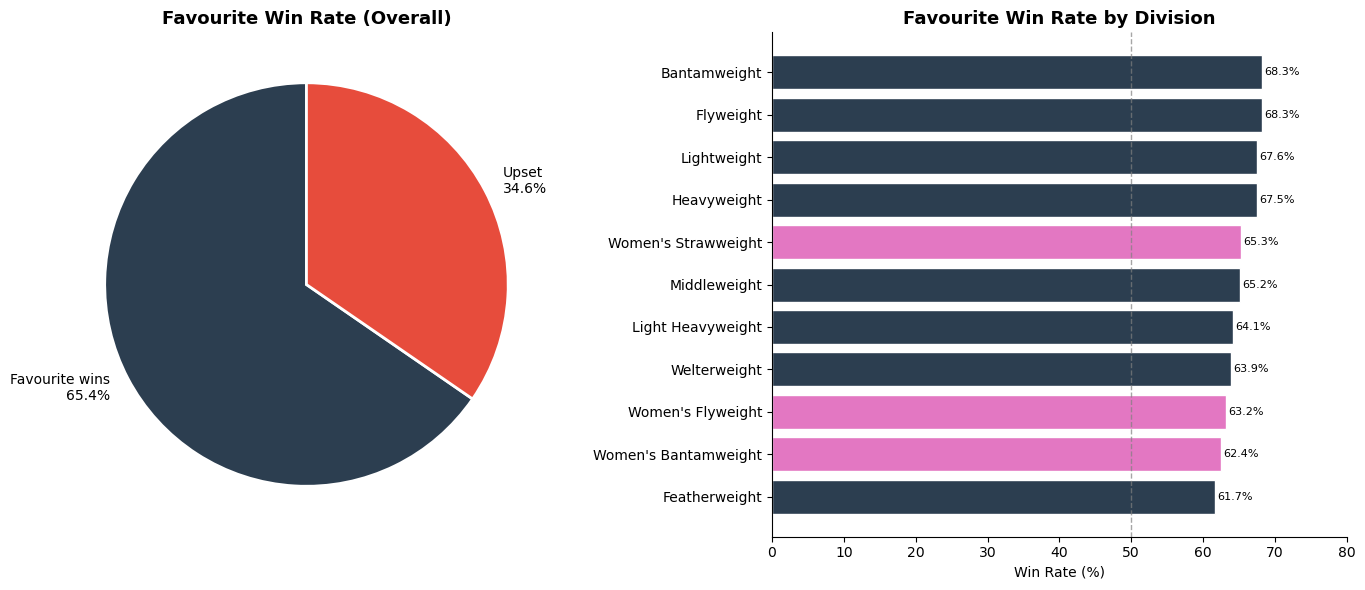

Overall favourite win rate: 65.4%
Fights analysed: 5922


In [27]:
# Load odds and convert to numeric
odds = pd.read_csv('../Data/UFC_betting_odds.csv', dtype=str, encoding='utf-8-sig')
odds['odds_1'] = pd.to_numeric(odds['odds_1'], errors='coerce')
odds['odds_2'] = pd.to_numeric(odds['odds_2'], errors='coerce')

# Average odds per fight across all bookmakers (each fight appears multiple times, one per bookmaker)
odds_agg = odds[odds['fight_url'].replace('', pd.NA).notna()].groupby('fight_url').agg(
    odds_1=('odds_1', 'mean'),
    odds_2=('odds_2', 'mean'),
    fighter_1=('fighter_1', 'first'),
    fighter_2=('fighter_2', 'first'),
).reset_index()

# Merge odds with fight results
fights_odds = fights_modern.merge(odds_agg, on='fight_url', how='inner')

# Remove draws and missing results
fights_odds = fights_odds[
    fights_odds['winner'].notna() &
    (fights_odds['winner'] != '') &
    (fights_odds['winner'] != 'Draw')
]

# Identify favourite (lower odds = favourite)
def get_favorite(row):
    if row['odds_1'] < row['odds_2']:
        return row['fighter_1_y']
    else:
        return row['fighter_2_y']

fights_odds['favorite'] = fights_odds.apply(get_favorite, axis=1)

# Check if favourite won
def favorite_won(row):
    if row['odds_1'] < row['odds_2']:
        return row['winner'] in [row['fighter_1_x'], row['fighter_1_y']]
    else:
        return row['winner'] in [row['fighter_2_x'], row['fighter_2_y']]

fights_odds['favorite_won'] = fights_odds.apply(favorite_won, axis=1)

# Overall favourite win rate
overall_fav_win = fights_odds['favorite_won'].mean() * 100

# Favourite win rate by division (min 30 fights, exclude Catch Weight)
fav_by_division = fights_odds.groupby('weight_class')['favorite_won'].agg(['mean', 'count'])
fav_by_division = fav_by_division[fav_by_division['count'] >= 30]
fav_by_division = fav_by_division[~fav_by_division.index.str.contains('Catch')]
fav_by_division['mean'] = fav_by_division['mean'] * 100
fav_by_division = fav_by_division.sort_values('mean')

# Two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left - overall pie chart
labels = ['Favourite wins\n' + str(round(overall_fav_win, 1)) + '%',
          'Upset\n' + str(round(100 - overall_fav_win, 1)) + '%']
axes[0].pie([overall_fav_win, 100 - overall_fav_win],
            labels=labels, colors=['#2C3E50', '#E74C3C'],
            autopct='', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Favourite Win Rate (Overall)', fontsize=13, fontweight='bold')

# Right - win rate by division
colors_div = ['#e377c2' if 'Women' in d else '#2C3E50' for d in fav_by_division.index]
bars = axes[1].barh(fav_by_division.index, fav_by_division['mean'], color=colors_div, edgecolor='white')
axes[1].axvline(x=50, color='gray', linestyle='--', linewidth=1, alpha=0.7)  # 50% reference line
for bar, val in zip(bars, fav_by_division['mean']):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 str(round(val, 1)) + '%', va='center', fontsize=8)
axes[1].set_title('Favourite Win Rate by Division', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_xlim(0, 80)

plt.tight_layout()
plt.show()

print('Overall favourite win rate: ' + str(round(overall_fav_win, 1)) + '%')
print('Fights analysed: ' + str(len(fights_odds)))

The betting market is right 65.4% of the time — meaning upsets occur in roughly 1 in 3 fights. 

This is a meaningful predictive signal but far from deterministic. 

The market is most reliable in Bantamweight and Flyweight (68.3%), where dominant champions like Demetrious Johnson and TJ Dillashaw created long stretches of predictable outcomes. 

Featherweight is the least predictable men's division at 61.7%, which reflects the era of competitive depth following José Aldo's reign. 

The relatively uniform distribution across divisions suggests the market is consistently calibrated rather than being better at predicting certain weight classes.

A 34.6% upset rate means that blindly betting the favourite would lose money in the long run due to bookmaker margins — the market is efficient but not perfectly so.

## 4. Fighter Profiles and Style Clustering

So far we have looked at what statistics correlate with winning. Now we go deeper: can we identify distinct fighting styles from the data? And once we have styles, do certain styles consistently beat others?

We use K-Means clustering to group fighters by their career statistics, letting the data define the styles rather than imposing labels manually.

### 4.1 Building Fighter Profiles

Before clustering, we need to build a profile for each fighter based on their average performance across all fights. We use fight-level statistics from ufc_fights.csv rather than the career averages from ufc_fighters.csv, because the fight data reflects actual in-cage performance rather than aggregated career stats.

In [28]:
# Define stats columns for fighter 1
numeric_fight_cols = [
    'significant_strikes_landed_1', 'significant_strikes_att_1',
    'sig_strikes_head_1', 'sig_strikes_body_1', 'sig_strikes_leg_1',
    'distance_strikes_1', 'clinch_strikes_1', 'ground_strikes_1',
    'takedowns_succ_1', 'takedowns_att_1',
    'control_time_seconds_1', 'subs_att_1', 'knockdowns_1'
]

# Convert fighter 1 columns to numeric
for col in numeric_fight_cols:
    fights_modern[col] = pd.to_numeric(fights_modern[col], errors='coerce')

# Same columns but for fighter 2
numeric_fight_cols_2 = [c.replace('_1', '_2') for c in numeric_fight_cols]
for col in numeric_fight_cols_2:
    fights_modern[col] = pd.to_numeric(fights_modern[col], errors='coerce')

# Extract fighter 1 stats and rename columns (remove _1 suffix)
f1_stats = fights_modern[['fighter_1'] + numeric_fight_cols].copy()
f1_stats.columns = ['fighter'] + [c.replace('_1', '') for c in numeric_fight_cols]

# Extract fighter 2 stats and rename columns (remove _2 suffix)
f2_stats = fights_modern[['fighter_2'] + numeric_fight_cols_2].copy()
f2_stats.columns = ['fighter'] + [c.replace('_1', '') for c in numeric_fight_cols]

# Combine and calculate average stats per fighter
all_stats = pd.concat([f1_stats, f2_stats])
fighter_profiles = all_stats.groupby('fighter').mean().reset_index()

# Add fight count per fighter
fight_counts = all_stats.groupby('fighter').size().reset_index(name='fight_count')
fighter_profiles = fighter_profiles.merge(fight_counts, on='fighter')

# Keep only fighters with 3+ fights (more reliable averages)
fighter_profiles = fighter_profiles[fighter_profiles['fight_count'] >= 3]

# Strike accuracy (landed / attempted) — replace 0 with NA to avoid division by zero
fighter_profiles['sig_strike_acc'] = fighter_profiles['significant_strikes_landed'] / fighter_profiles['significant_strikes_att'].replace(0, pd.NA)
fighter_profiles['td_acc'] = fighter_profiles['takedowns_succ'] / fighter_profiles['takedowns_att'].replace(0, pd.NA)

# Style ratios (0.001 added to avoid division by zero)
fighter_profiles['striking_ratio']  = fighter_profiles['significant_strikes_landed'] / (fighter_profiles['significant_strikes_landed'] + fighter_profiles['takedowns_succ'] + 0.001)
fighter_profiles['grappling_ratio'] = fighter_profiles['control_time_seconds'] / (fighter_profiles['control_time_seconds'] + fighter_profiles['significant_strikes_landed'] + 0.001)

# Summary
print('Fighter profiles built: ' + str(len(fighter_profiles)))
print(fighter_profiles[['fighter', 'significant_strikes_landed', 'takedowns_succ', 'control_time_seconds', 'fight_count']].head(10).to_string())

Fighter profiles built: 1666
                  fighter  significant_strikes_landed  takedowns_succ  control_time_seconds  fight_count
1               AJ Dobson                   96.000000        1.250000            106.000000            4
2             AJ Fletcher                   76.500000        1.000000            153.000000            4
4          Aaron Phillips                   39.500000        0.750000            108.500000            4
6             Aaron Riley                   52.000000        0.000000              0.000000            3
7              Aaron Rosa                         NaN             NaN                   NaN            3
8           Aaron Simpson                   76.000000        3.500000            335.500000            9
11   Abdul Razak Alhassan                   45.000000        0.357143             55.071429           14
14          Abel Trujillo                   49.636364        1.363636            103.181818           11
16            Abu Azaitar 

### 4.2 K-Means Clustering: Finding Fighting Styles

Cluster profiles:
                     significant_strikes_landed  sig_strikes_head  sig_strikes_body  sig_strikes_leg  distance_strikes  clinch_strikes  ground_strikes  takedowns_succ  control_time_seconds  subs_att  knockdowns
style                                                                                                                                                                                                             
High Volume Striker                       135.1              40.2              15.2             12.2              55.8             7.9             3.9             0.8                 105.9       0.2         0.2
Low Activity                               38.9              12.2               4.0              3.3              14.1             2.9             2.5             0.7                  87.8       0.3         0.1
Technical Striker                          82.0              25.4               8.7              6.8              32.6             4.9    

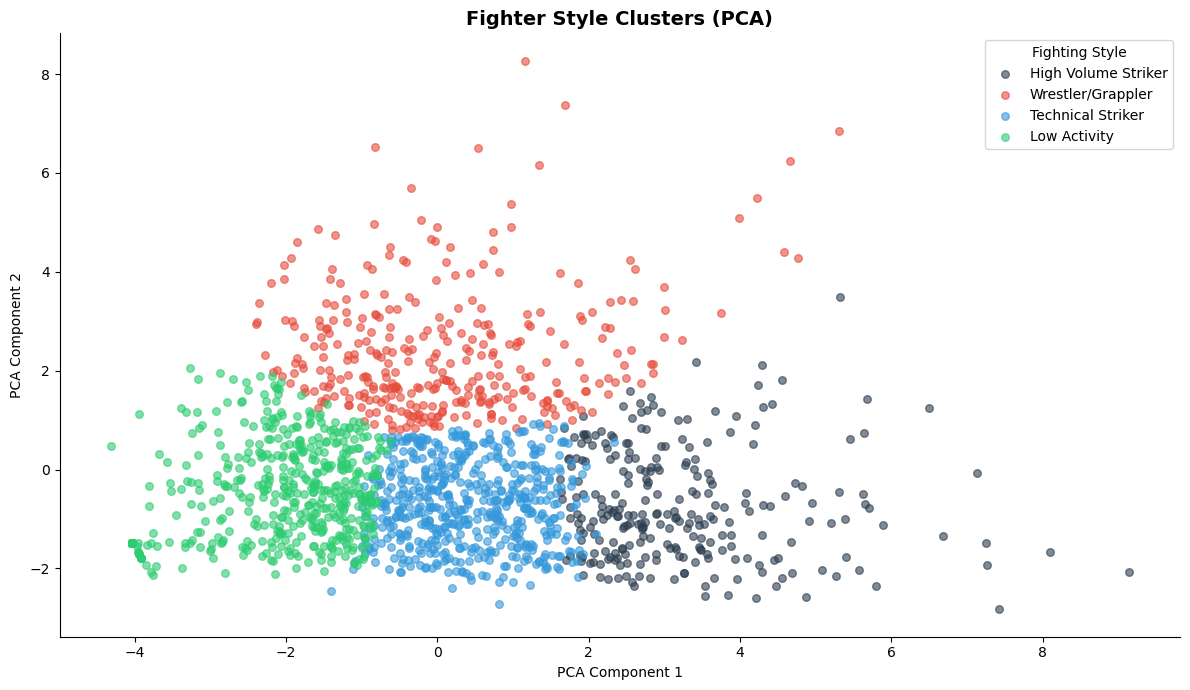

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Features used for clustering
cluster_features = [
    'significant_strikes_landed',
    'sig_strikes_head',
    'sig_strikes_body',
    'sig_strikes_leg',
    'distance_strikes',
    'clinch_strikes',
    'ground_strikes',
    'takedowns_succ',
    'control_time_seconds',
    'subs_att',
    'knockdowns'
]

# Prepare data — fill missing values with 0
X = fighter_profiles[cluster_features].fillna(0)

# Scale features so all are on the same scale (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means: group fighters into 4 clusters based on their stats
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
fighter_profiles['cluster'] = kmeans.fit_predict(X_scaled)

# Assign a readable label to each cluster
cluster_labels = {
    0: 'High Volume Striker',
    1: 'Wrestler/Grappler',
    2: 'Technical Striker',
    3: 'Low Activity'
}
fighter_profiles['style'] = fighter_profiles['cluster'].map(cluster_labels)

# PCA: reduce 11 features down to 2 dimensions for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fighter_profiles['pca_1'] = X_pca[:, 0]
fighter_profiles['pca_2'] = X_pca[:, 1]

# Print average stats per cluster
cluster_means = fighter_profiles.groupby('style')[cluster_features].mean()
print('Cluster profiles:')
print(cluster_means.round(1).to_string())

# Plot clusters in 2D PCA space
colors = {
    'High Volume Striker': '#2C3E50',
    'Wrestler/Grappler':   '#E74C3C',
    'Technical Striker':   '#3498DB',
    'Low Activity':        '#2ecc71'
}

fig, ax = plt.subplots(figsize=(12, 7))
for style, color in colors.items():
    mask = fighter_profiles['style'] == style
    ax.scatter(fighter_profiles[mask]['pca_1'],
               fighter_profiles[mask]['pca_2'],
               c=color, alpha=0.6, s=30, label=style)

ax.set_title('Fighter Style Clusters (PCA)', fontsize=14, fontweight='bold')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.legend(title='Fighting Style')
plt.tight_layout()
plt.show()

### 4.3 Interpreting the Clusters

The clustering algorithm found 4 distinct groups. To understand what each cluster represents, we look at the average statistics per cluster and identify well-known fighters in each group.

In [30]:
# Average stats per cluster
print('Average stats per cluster:')
print(cluster_means[['significant_strikes_landed', 'takedowns_succ',
                      'control_time_seconds', 'subs_att', 'sig_strikes_leg',
                      'distance_strikes', 'ground_strikes']].round(1).to_string())

print()

# Check which cluster well-known fighters belong to
known_fighters = ['Jon Jones', 'Khabib Nurmagomedov', 'Conor McGregor',
                  'Anderson Silva', 'Georges St-Pierre', 'Demetrious Johnson',
                  'Israel Adesanya', 'Charles Oliveira', 'Islam Makhachev',
                  'Kamaru Usman', 'Max Holloway', 'Justin Gaethje',
                  'Dustin Poirier', 'Colby Covington', 'Tony Ferguson']

known = fighter_profiles[fighter_profiles['fighter'].isin(known_fighters)][['fighter', 'cluster']]

print('Known fighters by cluster:')
for cluster in range(4):
    fighters_in = known[known['cluster'] == cluster]['fighter'].tolist()
    print('  Cluster ' + str(cluster) + ': ' + ', '.join(fighters_in))

Average stats per cluster:
                     significant_strikes_landed  takedowns_succ  control_time_seconds  subs_att  sig_strikes_leg  distance_strikes  ground_strikes
style                                                                                                                                             
High Volume Striker                       135.1             0.8                 105.9       0.2             12.2              55.8             3.9
Low Activity                               38.9             0.7                  87.8       0.3              3.3              14.1             2.5
Technical Striker                          82.0             0.7                  87.4       0.2              6.8              32.6             3.5
Wrestler/Grappler                          74.3             2.3                 263.9       0.5              4.9              23.1             8.7

Known fighters by cluster:
  Cluster 0: Israel Adesanya, Jon Jones, Justin Gaethje, Max Ho